In [2]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

from scipy.ndimage import convolve
import tifffile

In [15]:
filepath = Path('./svx_acc.npy')
assert filepath.exists()
acc = np.load(filepath)
acc.shape

(1000, 2000, 1040)

In [3]:
t = 10 * 24

# Concentration
N_gc = (0.1e-3) * (10e9)    # Injection volume (1 uL) x AAV Density (gc/mL)
sigma = 200                 # um
KD = N_gc / (sigma * np.sqrt(2 * np.pi))

p = 2.365e-5

# Fluorescence
n = 1         # Hill Constant
H = 24 * 5     # 10 days, in hours units
KF = 100 # (KD*p)/2
FMax = 100
FN = 10

In [ ]:
N_gc

1000000.0

: 

In [17]:
def calc_brightness(dose, t):
    cell_sat = FMax * (dose / (KF + dose))
    hill = np.pow(t, n) / (np.pow(H, n) + np.pow(t, n))
    return cell_sat * hill

In [19]:
fluorescence = calc_brightness(acc, t)

In [20]:
import numpy as np

def make_3d_gaussian(shape, mean=(0, 0, 0), std=(1, 1, 1)):
    """
    Generates a 3D Gaussian array.

    Args:
        shape (tuple): The shape of the output array (e.g., (100, 100, 100)).
        mean (tuple): The mean (center) of the Gaussian (mu_x, mu_y, mu_z).
        std (tuple): The standard deviation (spread) in each dimension (sigma_x, sigma_y, sigma_z).

    Returns:
        np.ndarray: A 3D numpy array with a Gaussian distribution.
    """
    # 1. Create coordinate arrays for each dimension
    # np.linspace creates a 1D array of evenly spaced values
    x = np.linspace(0, shape[0], shape[0])
    y = np.linspace(0, shape[1], shape[1])
    z = np.linspace(0, shape[2], shape[2])

    # Adjust coordinates to be centered around the mean
    x = x - mean[0]
    y = y - mean[1]
    z = z - mean[2]

    # 2. Create 3D meshgrid
    # This expands the 1D arrays into 3D grids of coordinates
    X, Y, Z = np.meshgrid(x, y, z, indexing='ij')

    # 3. Calculate the Gaussian function
    # The general formula for a 3D Gaussian is A * exp(-((x-mu_x)^2 / (2*sigma_x^2) + ...))
    # This example uses A=1 and assumes the centering done in step 1.
    gaussian = np.exp(
        -0.5 * (
            (X**2 / std[0]**2) +
            (Y**2 / std[1]**2) +
            (Z**2 / std[2]**2)
        )
    )

    return gaussian

# Example usage:
# Create a 3D Gaussian array of shape (64, 64, 64), centered at (32, 32, 32)
# with a standard deviation of 10 in all dimensions.
shape = (64, 64, 64)
mean = (shape[0] // 2, shape[1] // 2, shape[2] // 2)
std = (10, 10, 10)

gaussian_data = make_3d_gaussian(shape, mean, std)

print(f"Shape of the 3D Gaussian array: {gaussian_data.shape}")
print(f"Maximum value (center): {np.max(gaussian_data)}")
print(f"Minimum value (edges): {np.min(gaussian_data)}")


Shape of the 3D Gaussian array: (64, 64, 64)
Maximum value (center): 0.9961374863286223
Minimum value (edges): 2.1342080710431698e-07


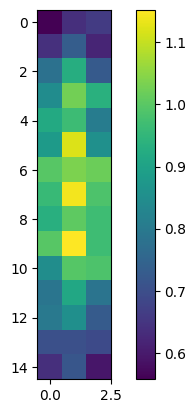

In [21]:
# Convolve with PSF
# Simulate with a weak anisotropic gaussian and white noise

psf_x = 5
psf_y = 15
psf_z = 5

psf = make_3d_gaussian((3, 15, 3), (1.5, 7.5, 1.5), std=(3, 7.5, 3))
psf += np.random.default_rng().uniform(0, 0.2, psf.shape)

plt.imshow(psf[1,:,:])
plt.colorbar()

In [24]:
imaged = convolve(fluorescence, psf)

In [25]:
noised = imaged + np.random.default_rng().uniform(0, 3, imaged.shape)

In [27]:
np.min(noised)

np.float64(2.8603343027455708e-09)

In [28]:
np.max(noised)

np.float64(1057.779336436977)

In [29]:
noised.shape

(1000, 2000, 1040)

In [30]:
tifffile.imwrite('simulated.tiff', noised[:,:,:250], compression='deflate')